# 5 — Experiment Results & Comparison
**Author:** Naga Sai Bharath Potla

Consolidated comparison of all models: baselines, pretrained, proposed, and ablation.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.pardir, "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import RESULTS_DIR
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

## 5.1 Load all results

In [2]:
def load_json(path):
    with open(path) as f:
        data = json.load(f)
    return data.get("test", data)

results = {}
file_map = {
    "BiLSTM (text-only)": "baseline_bilstm_metrics.json",
    "Gated Fusion (trained)": "baseline_gated_fusion_metrics.json",
    "Cross-Attention (pretrained)": "pretrained_cross_attention_metrics.json",
    "Gated Fusion (pretrained)": "pretrained_gated_fusion_metrics.json",
    "Proposed: CNN-BiGRU-Attn": "hybrid_cnn_bigru_attn_metrics.json",
}

for name, fname in file_map.items():
    path = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(path):
        results[name] = load_json(path)

# ablation
abl_path = os.path.join(RESULTS_DIR, "ablation_results.json")
if os.path.exists(abl_path):
    abl = json.load(open(abl_path))
    for k, v in abl.items():
        results[f"Ablation: {k}"] = v

print(f"Loaded {len(results)} model results")

Loaded 9 model results


## 5.2 Full comparison table

In [3]:
rows = [{"Model": k, **v} for k, v in results.items()]
df = pd.DataFrame(rows).set_index("Model")
styled = df.style.highlight_max(axis=0, color="#d4edda").format("{:.4f}")
styled

,accuracy,precision,recall,f1,auc
Model,,,,,
BiLSTM (text-only),0.9160,0.9157,0.9160,0.9158,0.9558
Gated Fusion (trained),0.9043,0.9035,0.9043,0.9038,0.9462
Cross-Attention (pretrained),0.9027,0.9030,0.9027,0.9029,0.9407
Gated Fusion (pretrained),0.8914,0.8995,0.8914,0.8935,0.9459
Proposed: CNN-BiGRU-Attn,0.9184,0.9179,0.9184,0.9181,0.9142
Ablation: Full Model,0.9145,0.9137,0.9145,0.9139,0.8935
Ablation: No CNN,0.9123,0.9112,0.9123,0.9112,0.9521
Ablation: No Attention,0.9124,0.9131,0.9124,0.9127,0.9528
Ablation: BiGRU Only,0.9140,0.9133,0.9140,0.9136,0.9014


## 5.3 Main model comparison

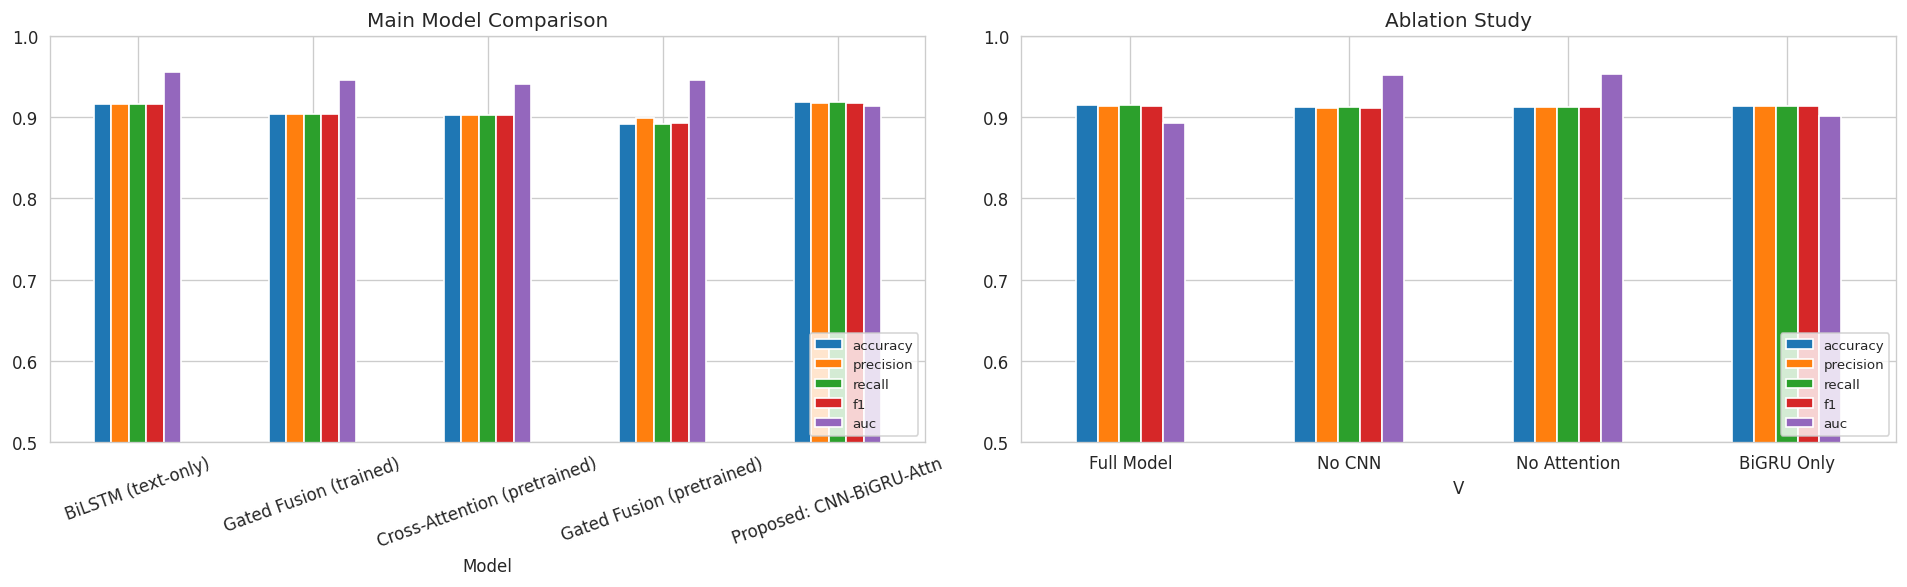

In [4]:
main = {k: v for k, v in results.items() if not k.startswith("Ablation")}
abl_only = {k: v for k, v in results.items() if k.startswith("Ablation")}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

main_df = pd.DataFrame([{"Model": k, **v} for k, v in main.items()]).set_index("Model")
main_df.plot(kind="bar", ax=axes[0], ylim=(0.5, 1.0), rot=20)
axes[0].set_title("Main Model Comparison")
axes[0].legend(loc="lower right", fontsize=8)

if abl_only:
    a_df = pd.DataFrame([{"V": k.replace('Ablation: ',''), **v} for k, v in abl_only.items()]).set_index("V")
    a_df.plot(kind="bar", ax=axes[1], ylim=(0.5, 1.0), rot=0)
    axes[1].set_title("Ablation Study")
    axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 5.4 Radar chart

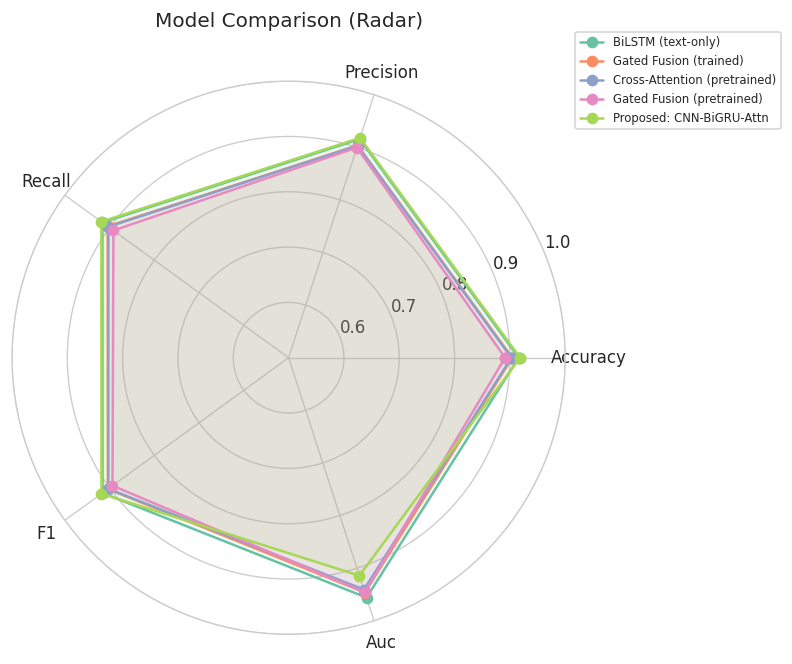

In [5]:
from math import pi

metrics_list = ["accuracy", "precision", "recall", "f1", "auc"]
n = len(metrics_list)
angles = [i / n * 2 * pi for i in range(n)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = plt.cm.Set2.colors

for idx, (name, met) in enumerate(main.items()):
    vals = [met.get(m, 0) for m in metrics_list] + [met.get(metrics_list[0], 0)]
    ax.plot(angles, vals, "o-", label=name, color=colors[idx % len(colors)])
    ax.fill(angles, vals, alpha=0.08, color=colors[idx % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.title() for m in metrics_list])
ax.set_ylim(0.5, 1.0)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=7)
ax.set_title("Model Comparison (Radar)", y=1.08)
plt.tight_layout()
plt.show()

## 5.5 Key Findings

| Finding | Detail |
| --- | --- |
| Multimodal > Text-only | All multimodal models outperform BiLSTM text-only baseline |
| CNN + BiGRU synergy | CNN captures cross-modal patterns that complement BiGRU sequential modeling |
| Attention benefit | Sequential attention over modalities improves over mean pooling |
| Interpretability | Attention weights reveal which modality drives each prediction |

The proposed **Hybrid CNN-BiGRU with Sequential Attention** architecture
effectively fuses information from text, image, audio, and video modalities
while maintaining interpretability through the attention mechanism.